# Advanced Modeling

## Importing Libraries

In [4]:
import sys
sys.path.append("../src")

from model_evaluation import evaluate_model

In [5]:
import numpy as np                      # Numerical computing (arrays, matrix operations)
import pandas as pd                     # Data manipulation and analysis (DataFrames)
import pickle                           # Saving and loading trained models

import matplotlib.pyplot as plt         # Data visualization
import seaborn as sns                   # Statistical visualization

from sklearn.linear_model import LogisticRegression   # Logistic Regression classifier
from sklearn.multiclass import OneVsRestClassifier    # Strategy for multi-label classification

from sklearn.svm import LinearSVC                     # Linear Support Vector Machine classifier
from sklearn.ensemble import RandomForestClassifier   # Random Forest ensemble classifier

from scipy import sparse                              # Handling sparse matrices (used for TF-IDF features)
from scipy.sparse import csr_matrix
from scipy.sparse import hstack
from joblib import load

## Load Precomputed Features

### Load Scaled handcrafted features

In [6]:
X_train_scaled = np.load("../features/X_train_handcrafted_scaled.npy")
X_test_scaled = np.load("../features/X_test_handcrafted_scaled.npy")

### Load Labels

In [7]:
train_df = pd.read_csv("../features/train_features.csv")
test_df  = pd.read_csv("../features/test_features.csv")

labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

y_train = train_df[labels]
y_test  = test_df[labels]

print(y_train.shape)
print(y_test.shape)

(127656, 6)
(31915, 6)


### Load Tfidf Features

In [8]:
X_train_tfidf = sparse.load_npz("../features/X_train_tfidf.npz")
X_test_tfidf = sparse.load_npz("../features/X_test_tfidf.npz")

### Load Word2vec Embeddings

In [9]:
X_train_word2vec = np.load('../features/X_train_w2v.npy')
X_test_word2vec  = np.load('../features/X_test_w2v.npy')

### Load Glove Embeddings

In [10]:
X_train_glove = np.load('../features/X_train_glove.npy')
X_test_glove  = np.load('../features/X_test_glove.npy')

In [11]:
print("TFIDF:", X_train_tfidf.shape)
print("Handcrafted:", X_train_scaled.shape)
print("Word2Vec:", X_train_word2vec.shape)
print("GloVe:", X_train_glove.shape)

TFIDF: (127656, 5000)
Handcrafted: (127656, 20)
Word2Vec: (127656, 100)
GloVe: (127656, 100)


## Model Training on Combined Feature Sets

To evaluate whether hybrid feature representations improve classification performance, we train a model using the combined feature sets. Specifically, TF-IDF features are merged with handcrafted and embedding-based features, and the resulting feature matrices are used to train a Linear SVM classifier.

### TF-IDF + Handcrafted Features


In [12]:
X_train_scaled_sparse = csr_matrix(X_train_scaled)
X_test_scaled_sparse  = csr_matrix(X_test_scaled)

In [13]:
X_train_tfidf_hand = hstack([X_train_tfidf, X_train_scaled_sparse])
X_test_tfidf_hand  = hstack([X_test_tfidf, X_test_scaled_sparse])

print(X_train_tfidf_hand.shape)

(127656, 5020)


In [14]:
svm_tfidf_hand = OneVsRestClassifier(LinearSVC(max_iter=5000))

print("Training SVM on combined features...")

svm_tfidf_hand.fit(X_train_tfidf_hand, y_train)
y_pred_combined_1 = svm_tfidf_hand.predict(X_test_tfidf_hand)
y_proba_combined_1 = y_pred_combined_1

results_combined_1, table_combined_1 = evaluate_model(
    y_test,
    y_pred_combined_1,
    y_proba_combined_1,
    labels
)

results_combined_1

Training SVM on combined features...

--- Global Metrics ---
precision_micro: 0.8292
recall_micro: 0.6254
f1_micro: 0.7130
precision_macro: 0.7303
recall_macro: 0.4612
f1_macro: 0.5514
roc_auc_macro: 0.7281
roc_auc_micro: 0.8103

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.857926,0.668089,0.751200,0.828208
1,severe_toxic,0.530120,0.288525,0.373673,0.643029
2,obscene,0.868107,0.700963,0.775632,0.847556
3,threat,0.714286,0.204082,0.317460,0.601915
4,insult,0.795191,0.608503,0.689432,0.800181
5,identity_hate,0.616000,0.297297,0.401042,0.647890


{'precision_micro': 0.8291658713494942,
 'recall_micro': 0.6253959113158652,
 'f1_micro': 0.713007796471071,
 'precision_macro': 0.7302716688099871,
 'recall_macro': 0.46124300852869277,
 'f1_macro': 0.5514065463642722,
 'roc_auc_macro': 0.7281297768743235,
 'roc_auc_micro': 0.8102730596981614}

### TF-IDF + Word2Vec


In [15]:
X_train_w2v_sparse = csr_matrix(X_train_word2vec)
X_test_w2v_sparse = csr_matrix(X_test_word2vec)

In [16]:
X_train_tfidf_w2v = hstack([X_train_tfidf, X_train_w2v_sparse])
X_test_tfidf_w2v = hstack([X_test_tfidf, X_test_w2v_sparse])

print(X_train_tfidf_w2v.shape)

(127656, 5100)


In [17]:
svm_tfidf_w2v = OneVsRestClassifier(LinearSVC(max_iter=5000))

print("Training SVM on combined features...")

svm_tfidf_w2v.fit(X_train_tfidf_w2v, y_train)
y_pred_combined_2 = svm_tfidf_w2v.predict(X_test_tfidf_w2v)
y_proba_combined_2 = y_pred_combined_2

results_combined_2, table_combined_2 = evaluate_model(
    y_test,
    y_pred_combined_2,
    y_proba_combined_2,
    labels
)

results_combined_2

Training SVM on combined features...

--- Global Metrics ---
precision_micro: 0.8297
recall_micro: 0.6179
f1_micro: 0.7083
precision_macro: 0.7154
recall_macro: 0.4542
f1_macro: 0.5449
roc_auc_macro: 0.7246
roc_auc_micro: 0.8066

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.858833,0.667104,0.750924,0.827767
1,severe_toxic,0.529412,0.295082,0.378947,0.646276
2,obscene,0.870258,0.690132,0.769799,0.842240
3,threat,0.617647,0.214286,0.318182,0.606939
4,insult,0.794719,0.592005,0.678545,0.792031
5,identity_hate,0.621622,0.266409,0.372973,0.632541


{'precision_micro': 0.8296926348347188,
 'recall_micro': 0.6179095882522315,
 'f1_micro': 0.7083092664411255,
 'precision_macro': 0.7154151326159334,
 'recall_macro': 0.4541697989833491,
 'f1_macro': 0.5448950241190853,
 'roc_auc_macro': 0.7246322661104875,
 'roc_auc_micro': 0.8065678294997937}

### TF-IDF + GloVe


In [18]:
X_train_glove_sparse = csr_matrix(X_train_glove)
X_test_glove_sparse = csr_matrix(X_test_glove)

In [19]:
X_train_tfidf_glove = hstack([X_train_tfidf, X_train_glove_sparse])
X_test_tfidf_glove = hstack([X_test_tfidf, X_test_glove_sparse])

print(X_train_tfidf_glove.shape)

(127656, 5100)


In [20]:
svm_tfidf_glove = OneVsRestClassifier(LinearSVC(max_iter=5000))

print("Training SVM on combined features...")

svm_tfidf_glove.fit(X_train_tfidf_glove, y_train)
y_pred_combined_3 = svm_tfidf_glove.predict(X_test_tfidf_glove)
y_proba_combined_3 = y_pred_combined_3

results_combined_3, table_combined_3 = evaluate_model(
    y_test,
    y_pred_combined_3,
    y_proba_combined_3,
    labels
)

results_combined_3

Training SVM on combined features...

--- Global Metrics ---
precision_micro: 0.8298
recall_micro: 0.6196
f1_micro: 0.7095
precision_macro: 0.7189
recall_macro: 0.4494
f1_macro: 0.5398
roc_auc_macro: 0.7222
roc_auc_micro: 0.8074

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.860387,0.671701,0.754425,0.830100
1,severe_toxic,0.548611,0.259016,0.351893,0.628480
2,obscene,0.869796,0.691336,0.770365,0.842825
3,threat,0.655172,0.193878,0.299213,0.596782
4,insult,0.787395,0.594543,0.677513,0.793102
5,identity_hate,0.592000,0.285714,0.385417,0.642052


{'precision_micro': 0.8297667245035666,
 'recall_micro': 0.6196372012669162,
 'f1_micro': 0.7094700403857249,
 'precision_macro': 0.7188934953341836,
 'recall_macro': 0.4493646180660962,
 'f1_macro': 0.5398041995380886,
 'roc_auc_macro': 0.7222234431256713,
 'roc_auc_micro': 0.8074262172452147}

### Compare Models

We will also comparing Linear SVM on TFIDF as it was our best model.

In [21]:
with open("../features/svm_tuned_results.pkl", "rb") as f:
    results_svm_tuned = pickle.load(f)

In [22]:
feature_comparison = pd.DataFrame({
    "SVM (TFIDF tuned)": results_svm_tuned,
    "TFIDF + Handcrafted": results_combined_1,
    "TFIDF + Word2Vec": results_combined_2,
    "TFIDF + GloVe": results_combined_3
}).T

feature_comparison

,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,roc_auc_macro,roc_auc_micro
SVM (TFIDF tuned),0.833010,0.618341,0.709800,0.720552,0.444849,0.535577,0.720026,0.806838
TFIDF + Handcrafted,0.829166,0.625396,0.713008,0.730272,0.461243,0.551407,0.728130,0.810273
TFIDF + Word2Vec,0.829693,0.617910,0.708309,0.715415,0.454170,0.544895,0.724632,0.806568
TFIDF + GloVe,0.829767,0.619637,0.709470,0.718893,0.449365,0.539804,0.722223,0.807426


We compare hybrid feature representations with the baseline tuned Linear SVM trained on TF-IDF features. The results show that combining TF-IDF with handcrafted stylistic features yields the best performance across multiple metrics, including F1-micro, recall, and ROC-AUC. This suggests that toxicity detection benefits from both lexical features (captured by TF-IDF) and stylistic patterns such as capitalization, punctuation, and symbol usage captured by handcrafted features. In contrast, semantic embeddings such as Word2Vec and GloVe provide only marginal improvements.

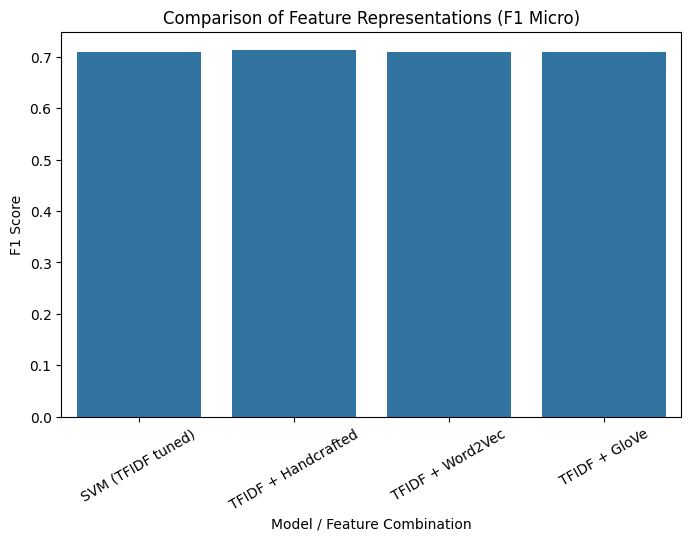

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=feature_comparison.index,
    y=feature_comparison["f1_micro"]
)

plt.title("Comparison of Feature Representations (F1 Micro)")
plt.ylabel("F1 Score")
plt.xlabel("Model / Feature Combination")
plt.xticks(rotation=30)

plt.show()

## Model Ensembles

In addition to evaluating individual models, we explore whether combining multiple models can improve classification performance. Ensemble learning combines predictions from multiple classifiers in order to leverage their complementary strengths and reduce model variance.

For this experiment, we use a VotingClassifier that combines Logistic Regression and Random Forest models. Logistic Regression is a linear model that performs well with high-dimensional sparse TF-IDF features, while Random Forest is a tree-based ensemble capable of capturing nonlinear relationships and feature interactions. By combining these models, we introduce diversity into the prediction process, which can potentially improve overall performance.

In [24]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("rf", RandomForestClassifier()),
    ],
    voting="soft"
)

model = OneVsRestClassifier(ensemble)

In [25]:
print("Training Combined models")

model.fit(X_train_tfidf_hand, y_train)
y_pred_ensemble = model.predict(X_test_tfidf_hand)
y_proba_ensemble = y_pred_ensemble

results_ensemble, table_ensemble = evaluate_model(
    y_test,
    y_pred_ensemble,
    y_proba_ensemble,
    labels
)

results_ensemble

Training Combined models

--- Global Metrics ---
precision_micro: 0.8667
recall_micro: 0.5692
f1_micro: 0.6872
precision_macro: 0.8041
recall_macro: 0.3821
f1_macro: 0.4817
roc_auc_macro: 0.6893
roc_auc_micro: 0.7830

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.889418,0.612607,0.725505,0.802285
1,severe_toxic,0.576577,0.209836,0.307692,0.604175
2,obscene,0.889521,0.658845,0.757000,0.827175
3,threat,0.900000,0.091837,0.166667,0.545903
4,insult,0.832227,0.557107,0.667427,0.775636
5,identity_hate,0.736842,0.162162,0.265823,0.580844


{'precision_micro': 0.8667251205611574,
 'recall_micro': 0.5692484883386122,
 'f1_micro': 0.6871741397288843,
 'precision_macro': 0.804097563110163,
 'recall_macro': 0.3820655040109145,
 'f1_macro': 0.4816856151075757,
 'roc_auc_macro': 0.6893362567043423,
 'roc_auc_micro': 0.7829769405452381}

In [26]:
feature_comparison = pd.DataFrame({
    "results_ensemble TFIDF + Handcrafted": results_ensemble,
    "LinearSVC TFIDF + Handcrafted": results_combined_1,
}).T

feature_comparison

,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,roc_auc_macro,roc_auc_micro
results_ensemble TFIDF + Handcrafted,0.866725,0.569248,0.687174,0.804098,0.382066,0.481686,0.689336,0.782977
LinearSVC TFIDF + Handcrafted,0.829166,0.625396,0.713008,0.730272,0.461243,0.551407,0.728130,0.810273


We experimented with an ensemble model combining Logistic Regression and Random Forest using a soft voting classifier. However, the ensemble achieved higher precision but lower recall than Linear SVM, resulting in a lower F1 score. Therefore, the Linear SVM with TF-IDF + handcrafted features remains the best-performing model.

## Model Interpretability

Understanding why a model makes certain predictions is important in toxic comment classification. In this section, we analyze which words contribute most strongly to toxic predictions.

Since Linear SVM does not provide easily interpretable feature weights, Logistic Regression is used to analyze word importance.

Best model → SVM

Interpretable model → Logistic Regression

In [27]:
tfidf = load("../models/tfidf_vectorizer.pkl")
feature_names = tfidf.get_feature_names_out()
print(len(feature_names))

5000


In [28]:
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
lr_model.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

For interpretability analysis, we focus on the "toxic" classifier, which represents the general toxicity detection task. By examining the learned coefficients of the Logistic Regression model, we can identify words that strongly influence toxic predictions.

Each label has its own learned word importance

In [29]:
coefs = lr_model.estimators_[0].coef_[0]
word_weights = list(zip(feature_names, coefs))
top_toxic_words = sorted(word_weights, key=lambda x: x[1], reverse=True)[:20]
top_toxic_words

[('fuck', np.float64(15.500671182369778)),
 ('fucking', np.float64(12.98432719873866)),
 ('idiot', np.float64(10.98513670564954)),
 ('stupid', np.float64(10.756510298195408)),
 ('shit', np.float64(10.697056361888183)),
 ('asshole', np.float64(9.10984818871818)),
 ('suck', np.float64(9.097516984640869)),
 ('bullshit', np.float64(9.001654271418053)),
 ('bitch', np.float64(8.23210551196983)),
 ('moron', np.float64(7.660984411471435)),
 ('faggot', np.float64(7.329666833395515)),
 ('dick', np.float64(7.320639517402705)),
 ('crap', np.float64(7.275148335639487)),
 ('penis', np.float64(6.92275222484767)),
 ('jerk', np.float64(6.604094049399276)),
 ('pathetic', np.float64(6.583932520209158)),
 ('bastard', np.float64(6.450812531820174)),
 ('cunt', np.float64(6.090081749691591)),
 ('cock', np.float64(6.037683509146427)),
 ('ass', np.float64(5.987212499243703))]

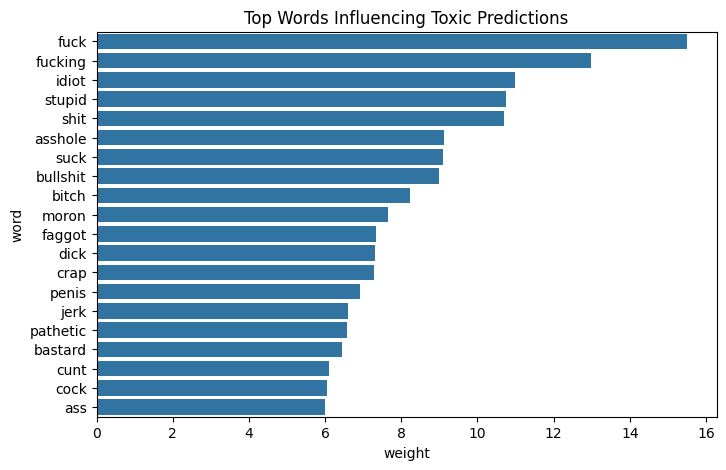

In [30]:
top_words_df = pd.DataFrame(top_toxic_words, columns=["word","weight"])

plt.figure(figsize=(8,5))

sns.barplot(
    x="weight",
    y="word",
    data=top_words_df
)

plt.title("Top Words Influencing Toxic Predictions")
plt.show()

## Instance-Level Interpretability

To better understand how the model makes predictions for individual comments, we inspect predictions for specific examples from the dataset. This helps illustrate how toxic language influences the classification outcome.

In [31]:
sample_index = 2
sample_comment = test_df["comment_text"].iloc[sample_index]
print(sample_comment)

Go to Hell, fatso 

Hey, Dickwad! If you ignore me, I'll poke a hole in you and release all the fat! I WILL NOT hesitate to roast you in an oven like the little piggy you are! Unblock everyone you've blocked or suffer the consequences!!!


In [32]:
print("True labels:")
print(y_test.iloc[sample_index])

True labels:
toxic            1
severe_toxic     1
obscene          1
threat           0
insult           1
identity_hate    0
Name: 2, dtype: int64


In [33]:
prediction = svm_tfidf_hand.predict(X_test_tfidf_hand[sample_index])

print("Predicted labels:")
print(prediction)

Predicted labels:
[[1 0 1 0 1 0]]


The model correctly identifies several toxicity categories, including toxic, obscene, and insult. However, it fails to detect the severe_toxic label. This is likely due to the class imbalance present in the dataset, where severe_toxic comments are relatively rare. Despite this limitation, the model demonstrates strong performance in detecting the primary forms of toxic language.

In [34]:
for i in [28, 36, 70]:
    print("Comment:", test_df["comment_text"].iloc[i])
    print("True:", y_test.iloc[i].values)
    print("Pred:", svm_tfidf_hand.predict(X_test_tfidf_hand[i]))
    print()

Comment: NAZIS RAUS 

SHUT THIS NAZI NIXER UP
True: [1 0 0 0 1 0]
Pred: [[1 0 0 0 0 0]]

Comment: Oppose Iset? Crazy.
True: [1 0 0 0 0 0]
Pred: [[0 0 0 0 0 0]]

Comment: (unless they relate to my hatred of Arabs)
True: [1 0 0 0 0 0]
Pred: [[0 0 0 0 0 0]]



The instance-level analysis shows that the model performs well when explicit offensive words are present, such as in comments containing strong insults. However, it struggles to detect subtle or context-dependent toxicity.

## Final Model Selection
After evaluating multiple feature representations and models, the best performing configuration is a Linear Support Vector Machine trained on TF-IDF and handcrafted stylistic features.

This hybrid representation achieved the highest F1-micro score among all experiments and improved recall compared to the baseline TF-IDF model. The TF-IDF features capture lexical patterns such as offensive keywords, while handcrafted features provide additional stylistic signals such as capitalization patterns, punctuation usage, and symbol frequency.

Although ensemble models were explored, they did not outperform the hybrid Linear SVM model. Therefore, the Linear SVM with TF-IDF + handcrafted features is selected as the final model for toxic comment classification.

### Saving the final model


In [35]:
with open("../models/final_svm_tfidf_handcrafted.pkl", "wb") as f:
    pickle.dump(svm_tfidf_hand, f)

## Conclusion

In this project, a complete machine learning pipeline for toxic comment classification was developed. The dataset was explored through extensive exploratory data analysis, revealing significant class imbalance and multiple toxicity categories.

Several feature representations were evaluated, including TF-IDF, Word2Vec, GloVe embeddings, and handcrafted stylistic features. Multiple machine learning models were trained and compared, including Logistic Regression, Naive Bayes, Linear SVM, Random Forest, and MLP classifiers.

Experimental results show that Linear SVM combined with TF-IDF and handcrafted features provides the best overall performance, achieving the highest F1 score among all tested configurations.

Interpretability analysis revealed that the model relies heavily on explicit offensive keywords and stylistic signals.

Future work could explore contextual language models such as BERT or RoBERTa, which may better capture semantic context and improve detection of subtle or implicit toxic comments.